#### Lab 02 — Language Models: Experiments

In [ ]:
import copy
import math
import random
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd

from preprocessing import *
from lab2.ngram_lm import NGramLanguageModel, build_vocabulary, count_ngrams, replace_oov
   
MIN_FREQ = 2       

docs = load_documents()
toks = doc_to_tok(docs)

train_docs, valid_docs, test_docs, train_sen, valid_sen, test_sen = prepare_corpus()


### Experiment 1 — Corpus statistics 

In [2]:
n_documents = len(docs)
n_sentences = len(toks)                                  
n_tokens = sum(len(s) for s in toks)
vocab_size_raw = len({t for s in toks for t in s})
vocab_size = len(build_vocabulary(toks, MIN_FREQ))

ngram_counts = {n: count_ngrams(toks, n) for n in (1, 2, 3)}

rows = []
for n, name in [(1, "Unigram"), (2, "Bigram"), (3, "Trigram")]:
    c = ngram_counts[n]
    n_unique = len(c)                                     
    n_singleton = sum(1 for v in c.values() if v == 1)    
    rows.append({"Model": name, "unique n-grams": n_unique,
                 "singletons": n_singleton})

print(f"documents={n_documents}\nsentences={n_sentences}\ntokens={n_tokens}\n"
      f"vocab(raw)={vocab_size_raw}\nvocab(min_freq={MIN_FREQ})={vocab_size}")
pd.DataFrame(rows)

documents=30000
sentences=634941
tokens=10944468
vocab(raw)=227644
vocab(min_freq=2)=108927


,Model,unique n-grams,singletons
0,Unigram,227645,118719
1,Bigram,2921510,2095992
2,Trigram,7062922,6058711


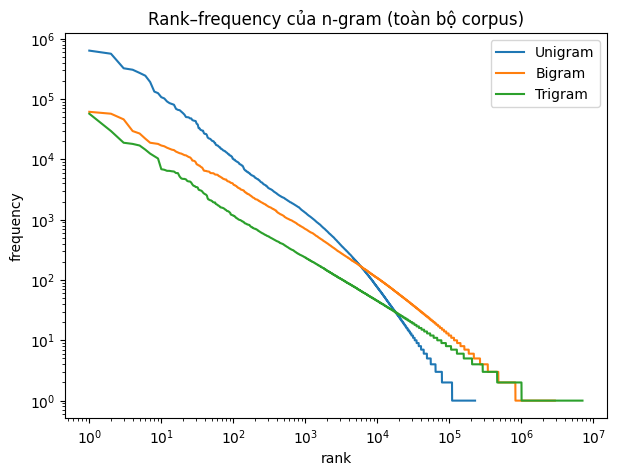

In [3]:
# Frequency distribution: vẽ rank–frequency trên trục log–log (Zipf)
fig, ax = plt.subplots(figsize=(7, 5))
for n, name in [(1, "Unigram"), (2, "Bigram"), (3, "Trigram")]:
    freqs = sorted(ngram_counts[n].values(), reverse=True)
    ax.loglog(range(1, len(freqs) + 1), freqs, label=name)
ax.set_xlabel("rank")
ax.set_ylabel("frequency")
ax.set_title("Rank–frequency của n-gram (toàn bộ corpus)")
ax.legend()
plt.show()


#### 15. Log probability

In [4]:
bigram = NGramLanguageModel(2, smoothing="laplace", min_freq=MIN_FREQ).fit(train_sen)

long_sen = max(test_sen, key=len)
print("độ dài câu:", len(long_sen))
print("P(S)     =", bigram.sentence_probability(long_sen))
print("log P(S) =", bigram.sentence_log_probability(long_sen))

độ dài câu: 277
P(S)     = 0.0
log P(S) = -2745.2071339954296


Tại sao log probability giúp tránh vấn đề numerical underflow?

Vì trong language model xác suất của cả câu được tính bằng tích xác suất của các từ trong câu mà xác suất của mỗi từ trong câu đều nằm trong khoảng [0,1] nên khi thực hiện phép nhân nhiều số như vaayj sẽ dẫn đến hiện tượng máy tính không thể biểu diễn chính xác được nên nó bị ép thành 0.0.
Vậy nên khi sử dụng log thì từ phép nhân các xác xuất ta chuyển sang thực hiện phép cộng log của các xác suất đó.

#### 16. Experiment 2 — MLE vs Laplace smoothing

In [5]:
models = {}
rows = []
for n, name in [(2, "Bigram"), (3, "Trigram")]:
    mle = NGramLanguageModel(n, smoothing="mle", min_freq=MIN_FREQ).fit(train_sen)
    laplace = copy.copy(mle)            
    laplace.smoothing = "laplace"
    models[(n, "mle")], models[(n, "laplace")] = mle, laplace
    for sm in ["mle", "laplace"]:
        m = models[(n, sm)]
        rows.append({
            "Model": f"{name} {sm.upper() if sm == 'mle' else 'Laplace'}",
            "Train PPL": m.perplexity(train_sen),
            "Valid PPL": m.perplexity(valid_sen),
            "Test PPL": m.perplexity(test_sen),
        })
exp2 = pd.DataFrame(rows).round(2)
exp2

,Model,Train PPL,Valid PPL,Test PPL
0,Bigram MLE,165.44,inf,inf
1,Bigram Laplace,3326.26,3793.54,3742.28
2,Trigram MLE,14.80,inf,inf
3,Trigram Laplace,17423.52,27316.67,27143.74


Tại sao kết quả lại như vậy?

Nhìn vào bảng kết quả ta thấy: 
- ở mô hình sử dụng smoothing = MLE cho kết quả trên tập train thấp hơn trên hai tập còn lại. Điều này có thể được suy ra từ việc MLE ước lượng xác suất count trên tập train nên các n-grams trên tập train có xác xuất cao. Ở các tập validation và tập test sẽ xuất hiện những cụm n-grams chưa từng xuất hện trong tập train nên dẫn tới xác xuất bằng 0 và khi tính perplexity được kết quả là inf.
- ở mô hình sử dụng smoothing = laplace giúp kết quả perplexity trên cả ba tập đều hữu hạn, nhưng vẫn có sự chênh lệch rõ giữa tập train với 2 tập còn lại. Các chỉ số của mô hình laplace đều được hữu hạn cho thấy tác dụng của việc cộng 1 vào mọi count,nhờ đó đảm bảo các từ trong vocab đều có xác suất khác 0 ngay cả nó không xuất hiện trong taapj train.
- Khi chuyển từ bigram sang trigram, perplexity trong kết quả này tăng mạnh đối với mô hình Laplace. Nguyên nhân là trigram sử dụng context gồm hai từ thay vì một từ, khiến context cụ thể hơn và thường có count thấp hơn. Với những context có count thấp hoặc chưa xuất hiện, công thức Laplace có thể cho xác suất của từ tiếp theo rất nhỏ, tiến gần về \(1/V\), từ đó làm perplexity tăng. 

#### 18. Bài tập tính Perplexity
P(w_1) = 0.5

P(w_2|w_1) = 0.25

P(w_3|w_2) = 0.5

P(w) = P(w_1) . P(w_2|w_1) . P(w_3|w_2) = 0.5 . 0.25 . 0.5 = 0.0625

PP(W) = exp(-1/3 . (ln(0.5) + ln(0.25) + ln(0.5))) = 2.5198421

P(w_1) = 0.5

P(w_2|w_1) = 0.1

P(w_3|w_2) = 0.5

P(w) = P(w_1) . P(w_2|w_1) . P(w_3|w_2) = 0.5 . 0.1 . 0.5 = 0.025

PP(W) = exp(-1/3 . (ln(0.5) + ln(0.25) + ln(0.5))) = 3.4199518933

Một xác xuất nhỏ cũng có thể làm perplexity thay đổi đáng kể?

Vì perplexity dùng log của một số trong khoảng [0,1] là một số âm rất nhỏ và khi lấy trung bình thì ppl sẽ tăng lên đáng kể. VD: ln(0.25) = -1.286, ln(0.1) = -2.303 => xác suất giảm 0.15 nhưng log probability tăng 0.916

In [6]:
def pp(probs):
    return math.exp(-sum(math.log(p) for p in probs) / len(probs))

print("Trường hợp 1:", pp([0.5, 0.25, 0.5]))
print("Trường hợp 2:", pp([0.5, 0.1, 0.5]))

Trường hợp 1: 2.519842099789746
Trường hợp 2: 3.4199518933533932


#### 19. Experiment 3 — Perplexity
So sánh unigram, bigram, trigram trên các tập train, validation, test

In [7]:
rows = []
for n, name in [(1, "Unigram"), (2, "Bigram"), (3, "Trigram")]:
    for sm in ["mle", "laplace"]:
        if (n, sm) not in models:
            if sm == "mle":
                models[(n, sm)] = NGramLanguageModel(n, smoothing="mle", min_freq=MIN_FREQ).fit(train_sen)
            else:
                models[(n, sm)] = copy.copy(models[(n, "mle")])
                models[(n, sm)].smoothing = "laplace"
        m = models[(n, sm)]
        rows.append({"Model": name, "Smoothing": sm, "Train": m.perplexity(train_sen),
                     "Validation": m.perplexity(valid_sen), "Test": m.perplexity(test_sen)})
exp3 = pd.DataFrame(rows).round(2)
exp3


,Model,Smoothing,Train,Validation,Test
0,Unigram,mle,1537.25,1357.24,1340.57
1,Unigram,laplace,1538.73,1361.23,1344.52
2,Bigram,mle,165.44,inf,inf
3,Bigram,laplace,3326.26,3793.54,3742.28
4,Trigram,mle,14.80,inf,inf
5,Trigram,laplace,17423.52,27316.67,27143.74


**Tác động của corpus size** — train với số document khác nhau, đo trên cùng một tập valid.


In [8]:
rows = []
for ratio in [0.1, 0.25, 0.5, 1.0]:
    sub_docs = train_docs[: int(len(train_docs) * ratio)]  
    sub = doc_to_tok(sub_docs)
    for n in (1, 2, 3):
        m = NGramLanguageModel(n, smoothing="laplace", min_freq=MIN_FREQ).fit(sub)
        rows.append({"train fraction": ratio, "# docs": len(sub_docs), "n": n, "vocab": len(m.vocab),
                     "Train PPL": m.perplexity(sub), "Valid PPL": m.perplexity(valid_sen)})
size_df = pd.DataFrame(rows).round(2)
size_df.pivot(index="train fraction", columns="n", values="Valid PPL").assign(
    vocab=size_df.groupby("train fraction")["vocab"].first())

n,1,2,3,vocab
train fraction,,,,
0.10,933.24,3160.10,12676.80,24989
0.25,1135.30,3600.30,18060.74,42680
0.50,1259.52,3762.21,22589.86,63934
1.00,1361.23,3793.54,27316.67,96027


Giải thích:

- Tại sao training perplexity thay đổi (khi tăng n)?

Chỉ số perplexity trên tập train thay đổi tùy theo bậc của n-gram, do mỗi bậc sử dụng lượng ngữ cảnh khác nhau. Dựa vào bảng đầu tiên, khi sử dụng smooothing = MLE, train perplexity đã giảm từ 1537,25 (unigram) xuống còn 165,44 (bigram) và 14,80 (trigram). Các n-gram bậc cao hơn cung cấp ngữ cảnh cụ thể hơn, cho phép mô hình gán xác suất cao hơn cho nhiều cụm từ mà nó đã gặp trong tập train. Tuy nhiên, với smoothing = Laplace, train perplexity lại cao hơn nhiều do một phần khối lượng xác suất cũng được phân bổ cho các từ hoặc n-gram chưa từng xuất hiện.

- Tại sao validation/test có thể không cải thiện?

Kết quả trên tập validation/test có thể không cải thiện vì mô hình chỉ được huấn luyện trên tập train, trong khi tập validaton/test lại chứa các ngữ cảnh hoặc n-gram chưa từng xuất hiện trong quá trình huấn luyện. Điều này thể hiện rõ đối với smoothing = MLE: mô hình bigram MLE có ppl trên tập train là 165,44 nhưng ppl trên tập validation/test là inf, trong khi mô hình trigram MLE có ppl trên tập train là 14,80 nhưng ppl trên tập validation/test cũng là inf. Laplace giúp tránh được xác suất bằng không, nhưng chỉ số PPL trên tập kiểm chứng vẫn ở mức cao: 3793,54 đối với bigram và 27316,67 đối với trigram.

- Dấu hiệu overfitting?

Dấu hiệu overfitting có tể là sự chênh lệch lớn giữa PPL trên tập train và tập validation. Ta có trigram laplace trên tập train là 17423,52, trong khi trên tập validation = 27316,67. Điều này cho thấy khả năng dự đoán hóa kém hơn, mặc dù khoảng cách này cũng có thể bị ảnh hưởng bởi độ thưa thớt của n-gram.

- Tác động của corpus size?

Việc thay đổi kích thước của tập train làm cho kết quả thu được trên cùng 1 tập validation của cả 3 model đều tăng. Tuy nhiên, điều đó cũng đồng nghĩa với việc vocab size cũng thay đổi có nhiêù từ hơn và cũng có ít từ bị đổi thành unk. Khi đó, model sẽ khó đoán chính xác một từ hơn và khiến cho perplexity tăng lên. Vì mỗi lần chạy dùng một bộ vocab khác nhau nên không thể so sánh trực tiếp các kết quả trên bằng với nhau.

#### 20. Application — Next-word prediction

In [9]:
def predict_next(model, context, k=3):
    next_word = model.next_word_distribution(context, top_k=k)
    if not next_word:
        return "Unseen context"
    return ", ".join(f"{w} {p:.3f}" for w, p in next_word)

random.seed(1)
lm = models[(3, "mle")]
rows = []
for s in random.sample([s for s in test_sen if len(s) >= 6], 10):   
    i = random.randrange(2, len(s))                                 
    context, actual = s[:i], s[i]                                  
    rows.append({"Context": " ".join(context[-2:]),                 
                 "Prediction": predict_next(lm, context),
                 "Actual next word": actual})
pd.set_option("display.max_colwidth", None)
pred_df = pd.DataFrame(rows)
pred_df

,Context,Prediction,Actual next word
0,scheduled posts,content 1.000,will
1,sometime in,"the 0.407, may 0.074, 2016 0.074",the
2,just not,"the 0.097, a 0.065, going 0.054",common
3,n posible,"<UNK> 0.088, </s> 0.066, a 0.055",sobre
4,over different,"active 0.200, muscle 0.200, time 0.200",types
5,do you,"have 0.129, think 0.118, want 0.079",have
6,we were,"able 0.067, in 0.041, going 0.039",enthralled
7,liquid biopsies,Unseen context,examinations
8,the tiles,"of 0.400, insure 0.200, </s> 0.200",may
9,at bella,"collina 0.667, vista 0.333",natural


In [10]:
ppl_long = exp3.melt(id_vars=["Model", "Smoothing"], value_vars=["Train", "Validation", "Test"],
                     var_name="Split", value_name="Perplexity")
ppl_long.insert(0, "Section", "perplexity")

pred_out = pred_df.assign(Section="next-word prediction", Model="Trigram", Smoothing="mle")

results = pd.concat([ppl_long, pred_out], ignore_index=True)[
    ["Section", "Model", "Smoothing", "Split", "Perplexity", "Context", "Prediction", "Actual next word"]]
results.to_csv("results.csv", index=False, encoding="utf-8-sig")
print("Đã ghi", len(results), "dòng vào results.csv")
results

Đã ghi 28 dòng vào results.csv


,Section,Model,Smoothing,Split,Perplexity,Context,Prediction,Actual next word
0,perplexity,Unigram,mle,Train,1537.25,NaN,NaN,NaN
1,perplexity,Unigram,laplace,Train,1538.73,NaN,NaN,NaN
2,perplexity,Bigram,mle,Train,165.44,NaN,NaN,NaN
3,perplexity,Bigram,laplace,Train,3326.26,NaN,NaN,NaN
4,perplexity,Trigram,mle,Train,14.80,NaN,NaN,NaN
5,perplexity,Trigram,laplace,Train,17423.52,NaN,NaN,NaN
6,perplexity,Unigram,mle,Validation,1357.24,NaN,NaN,NaN
7,perplexity,Unigram,laplace,Validation,1361.23,NaN,NaN,NaN
8,perplexity,Bigram,mle,Validation,inf,NaN,NaN,NaN
9,perplexity,Bigram,laplace,Validation,3793.54,NaN,NaN,NaN


#### 21. Application — Sentence ranking

In [11]:
def sentence_ranking(model, context, candidates):
    ctx = context.lower().split()
    scores = {}
    for cand in candidates:
        toks = cand.lower().split()
        scores[cand] = model.continuation_log_probability(ctx, toks) / len(toks)   # log P trung bình mỗi từ
    return scores

RANKING_TASKS = [
    ("machine learning", ["is useful for NLP", "banana computer quickly", "studies language models"]),
    ("i would like", ["to sleep", "a milktea", "to die"]),
    ("the price of", ["the house is high", "peacefull", "running quickly blue"]),
]
rows = []
for context, candidates in RANKING_TASKS:
    mle = sentence_ranking(models[(2, "mle")], context, candidates)
    lap = sentence_ranking(models[(2, "laplace")], context, candidates)
    for rank, cand in enumerate(sorted(candidates, key=lambda c: lap[c], reverse=True), 1):   # xếp hạng theo Laplace
        rows.append({"Context": context, "Rank": rank, "Candidate": cand,
                     "log P / token (MLE)": mle[cand], "log P / token (Laplace)": lap[cand]})
pd.DataFrame(rows).set_index(["Context", "Rank"]).round(2)

Candidate  log P / token (MLE)  \
Context          Rank                                                 
machine learning 1           is useful for NLP                -6.41   
                 2     studies language models                 -inf   
                 3     banana computer quickly                 -inf   
i would like     1                   a milktea                -3.13   
                 2                    to sleep                -4.84   
                 3                      to die                -4.96   
the price of     1                   peacefull                -4.25   
                 2           the house is high                -4.70   
                 3        running quickly blue                 -inf   

                       log P / token (Laplace)  
Context          Rank                           
machine learning 1                       -8.73  
                 2                      -11.26  
                 3                      -11.48  
i would like     1                       -4.36  
                 2                       -6.04  
                 3                       -6.16  
the price of     1                       -4.62  
                 2                       -5.86  
                 3                      -10.34

## 22. Error analysis

Lấy ngẫu nhiên các vị trí trong test, so top-1 prediction với từ thật.

In [12]:
random.seed(0)
lm = models[(3, "laplace")]
cases = []
for s in random.sample(test_sen, 300):
    if len(s) < 3:
        continue
    i = random.randrange(2, len(s))
    ctx, real = s[:i], s[i]
    pred, p_pred = lm.next_word_distribution(ctx, top_k=1)[0]
    cases.append({"context": " ".join(ctx[-2:]), "prediction": pred, "p(pred)": p_pred,
                  "expected": real, "p(expected)": lm.probability(ctx, real),
                  "correct": pred == real, "context seen": lm._context_input(ctx) in lm.context_counts})
cases = pd.DataFrame(cases)
print("top-1 accuracy:", cases["correct"].mean())
display(cases[cases.correct].head(10))
display(cases[~cases.correct].head(20))

top-1 accuracy: 0.10915492957746478


,context,prediction,p(pred),expected,p(expected),correct,context seen
17,all rights,reserved,0.001653,reserved,0.001653,True,True
22,other surrounding,areas,0.000021,areas,0.000021,True,True
37,easy it,is,0.000354,is,0.000354,True,True
44,back in,the,0.001480,the,0.001480,True,True
47,excellence in,the,0.000073,the,0.000073,True,True
51,thank you,for,0.005378,for,0.005378,True,True
61,opposite of,what,0.000104,what,0.000104,True,True
70,better connect,with,0.000021,with,0.000021,True,True
91,cool is,that,0.000031,that,0.000031,True,True
93,s another,thing,0.000042,thing,0.000042,True,True


,context,prediction,p(pred),expected,p(expected),correct,context seen
0,if you,are,0.017056,have,0.011769,False,True
1,like to,see,0.000808,share,0.000440,False,True
2,htc evo,braganca,0.000010,4g,0.000010,False,False
3,a call,at,0.000488,for,0.000135,False,True
4,held on,the,0.000250,june,0.000010,False,True
5,with matt,gilks,0.000021,while,0.000010,False,True
6,trademark of,the,0.000042,wizards,0.000010,False,True
7,these violations,</s>,0.000021,and,0.000010,False,True
8,into app,through,0.000021,even,0.000010,False,True
9,not especially,significant,0.000021,if,0.000010,False,True


#### 23. Context length 

In [13]:
def unseen_rate(model, eval_corpus):
    """% n-gram (tính theo token, có trọng số count) trong eval chưa từng xuất hiện trong train."""
    eval_mapped = replace_oov(eval_corpus, model.vocab)          # OOV -> <UNK> giống lúc model chấm điểm
    ev = count_ngrams(eval_mapped, model.n)
    unseen = sum(c for g, c in ev.items() if g not in model.ngram_counts)
    return 100 * unseen / sum(ev.values())

ppl = exp3.set_index(["Model", "Smoothing"])
rows = []
for n, name in [(1, "Unigram"), (2, "Bigram"), (3, "Trigram")]:
    m = models[(n, "laplace")]
    rows.append({"Model": name,
                 "Train PPL (Laplace)": ppl.loc[(name, "laplace"), "Train"],
                 "Valid PPL (Laplace)": ppl.loc[(name, "laplace"), "Validation"],
                 "Test PPL (Laplace)": ppl.loc[(name, "laplace"), "Test"],
                 "# unique n-grams": len(m.ngram_counts),
                 "% unseen n-grams (test)": unseen_rate(m, test_sen)})
pd.DataFrame(rows).round(2)

,Model,Train PPL (Laplace),Valid PPL (Laplace),Test PPL (Laplace),# unique n-grams,% unseen n-grams (test)
0,Unigram,1538.73,1361.23,1344.52,96027,0.00
1,Bigram,3326.26,3793.54,3742.28,2316562,18.44
2,Trigram,17423.52,27316.67,27143.74,5747447,55.58


Context dài hơn có luôn tốt hơn không?

Context dài hơn không phải lúc nào cũng tốt hơn. Khi ngữ cảnh càng nhiều thì số lượng n-gram duy nhất tăng từ 96027 lên 5747447	 trong khi tỉ lệ n-gram trong tập test chưa từng xuất hiện cũng tăng lên. Chỉ số perplexity trên tập validation đạt 1361.23 ở unigram tăng rất nhiều lần so với 37316,67 ở trigram. Điều này cho thấy ngữ cảnh dài hơn giúp mô hình quan sát được nhiều context hơn những cũng khiến nhiều n-gram không xuất hiện trong tập train. 